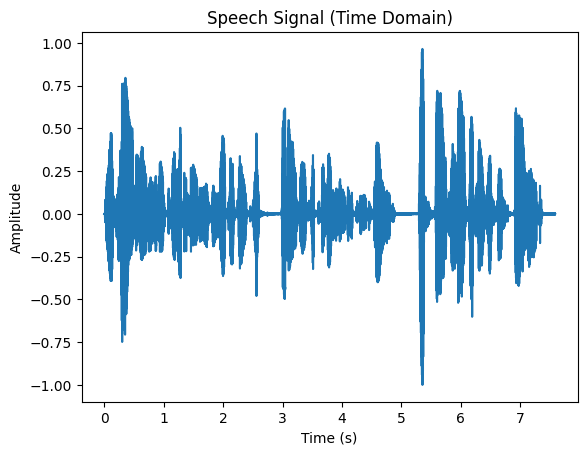

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load audio
fs, signal = wavfile.read('/content/LJ037-0171.wav')

# Normalize if needed
signal = signal / np.max(np.abs(signal))

# Time axis
t = np.linspace(0, len(signal)/fs, len(signal))

plt.figure()
plt.plot(t, signal)
plt.title("Speech Signal (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

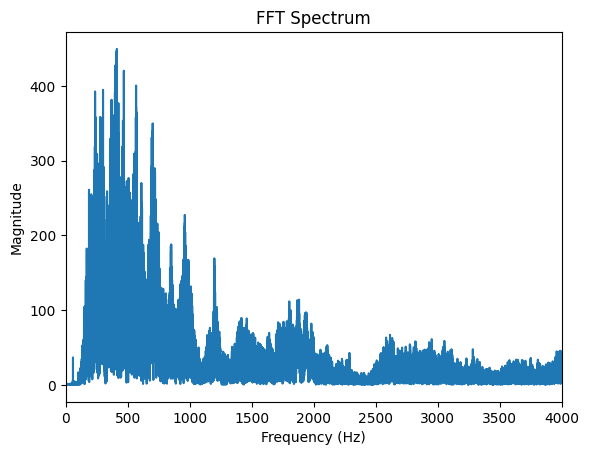

In [10]:
# FFT
N = len(signal)
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, 1/fs)

# Only positive frequencies
mask = freqs >= 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

plt.figure()
plt.plot(freqs, fft_vals)
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 4000)  # Speech-relevant range
plt.show()

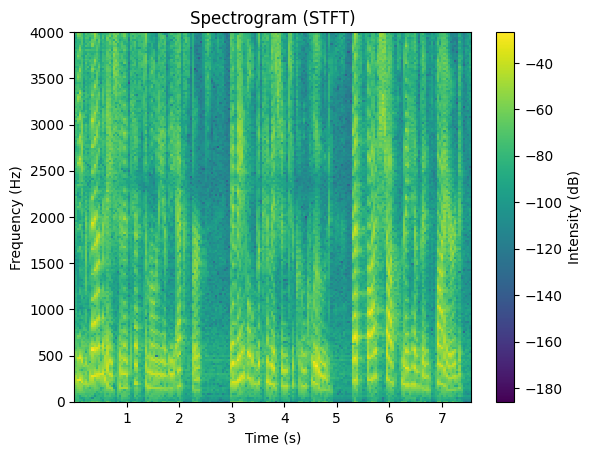

In [11]:
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(signal, fs, nperseg=1024)

plt.figure()
plt.pcolormesh(t, f, 10*np.log10(Sxx))
plt.title("Spectrogram (STFT)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 4000)
plt.colorbar(label='Intensity (dB)')
plt.show()

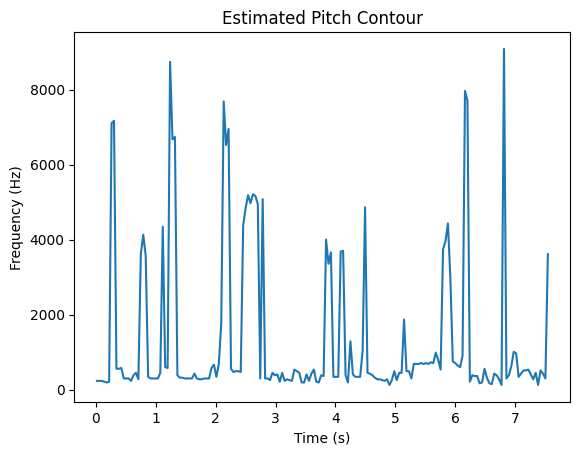

In [12]:
pitch_contour = []

for i in range(Sxx.shape[1]):
    spectrum_slice = Sxx[:, i]
    peak_idx = np.argmax(spectrum_slice)
    pitch_contour.append(f[peak_idx])

plt.figure()
plt.plot(t, pitch_contour)
plt.title("Estimated Pitch Contour")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

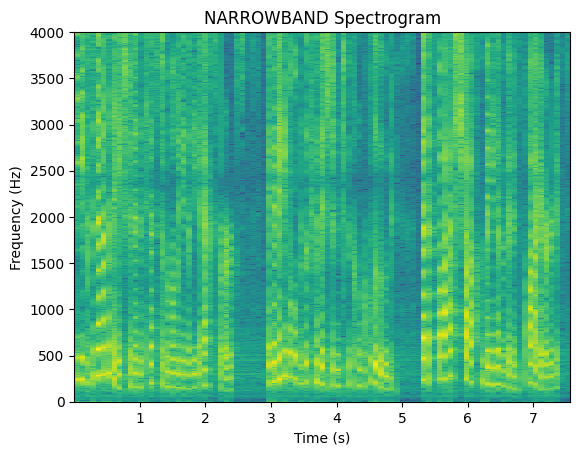

In [13]:
f1, t1, Sxx1 = spectrogram(signal, fs, nperseg=2048)

plt.figure()
plt.pcolormesh(t1, f1, 10*np.log10(Sxx1))
plt.title("NARROWBAND Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 4000)
plt.show()

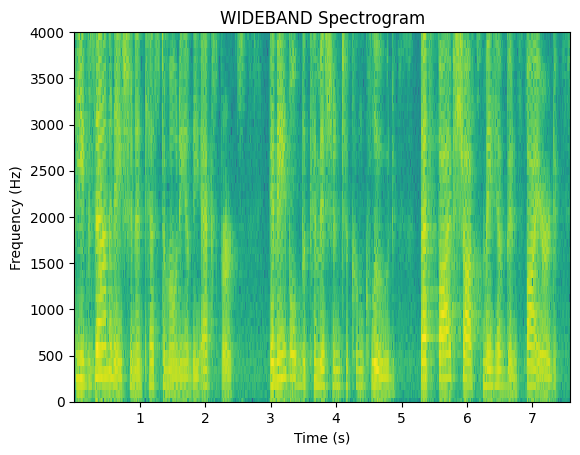

In [14]:
f2, t2, Sxx2 = spectrogram(signal, fs, nperseg=256)

plt.figure()
plt.pcolormesh(t2, f2, 10*np.log10(Sxx2))
plt.title("WIDEBAND Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 4000)
plt.show()

Approx Formant Frequencies (Hz): [ 398.36425781 1991.82128906 3951.34277344]


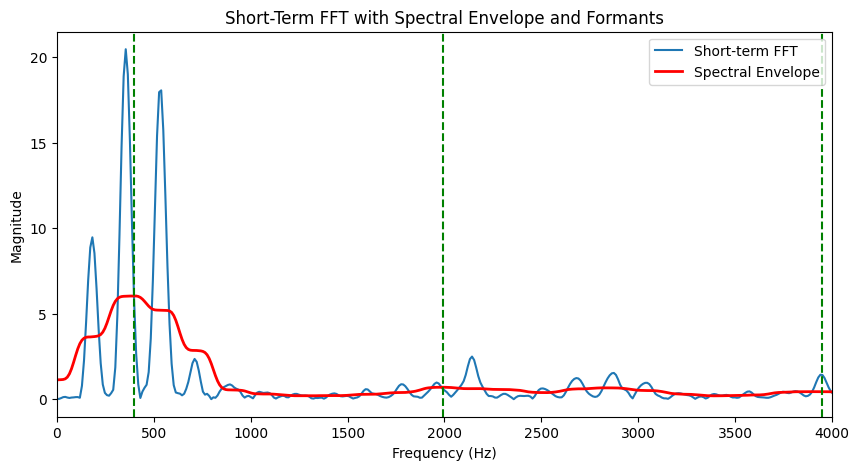

In [15]:
# ================================
# SHORT-TERM FFT (ONE WINDOW)
# ================================

# Select a short segment (e.g., 30 ms window)
win_length = int(0.03 * fs)   # 30 ms
start_sample = int(0.5 * len(signal))  # middle of signal

frame = signal[start_sample : start_sample + win_length]

# Apply Hamming window
window = np.hamming(len(frame))
frame_windowed = frame * window

# FFT of the frame
N_frame = len(frame_windowed)
fft_frame = np.fft.fft(frame_windowed, n=2048)  # zero-padding for better resolution
freqs_frame = np.fft.fftfreq(2048, 1/fs)

# Keep positive frequencies
mask = freqs_frame >= 0
freqs_frame = freqs_frame[mask]
fft_mag = np.abs(fft_frame[mask])

# ================================
# SPECTRAL ENVELOPE (SMOOTHING)
# ================================

# Simple smoothing using moving average
window_size = 50
envelope = np.convolve(fft_mag, np.ones(window_size)/window_size, mode='same')

# ================================
# FIND APPROX FORMANT LOCATIONS
# ================================

from scipy.signal import find_peaks

# Find peaks in envelope
peaks, _ = find_peaks(envelope, distance=100)

formant_freqs = freqs_frame[peaks]

# Keep only speech-relevant formants (0–4000 Hz)
formant_freqs = formant_freqs[formant_freqs < 4000]

# Take first 3 prominent ones
formant_freqs = formant_freqs[:3]

print("Approx Formant Frequencies (Hz):", formant_freqs)

# ================================
# PLOT
# ================================

plt.figure(figsize=(10,5))
plt.plot(freqs_frame, fft_mag, label="Short-term FFT")
plt.plot(freqs_frame, envelope, 'r', linewidth=2, label="Spectral Envelope")

# Mark formants
for f in formant_freqs:
    plt.axvline(f, color='g', linestyle='--')

plt.title("Short-Term FFT with Spectral Envelope and Formants")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 4000)
plt.legend()
plt.show()